In [1]:
# ============================================================
#  SETTINGS — 모든 설정을 여기서 관리
# ============================================================

# --- ID ---
BRAND_ID         = "brand2"
VARIABLE_SET_ID  = 8          # variable_set 번호
CONFIG_SET_ID    = 105          # config_set 번호
GROUP_IDX        = 3          # var_group 행 인덱스 (0=group1, 1=group2, ...)

# --- S3 ---
ENV_PATH         = "/Users/ansaejin/Desktop/agent-modeler/.env.local"
S3_PREFIX        = "model_result"

# --- 타겟 ---
TARGET_COLUMN    = "Total Revenue" # Total Revenue, Total Volume

# --- Note ---
NOTE             = f"하이퍼파라미터 시작, Target : {TARGET_COLUMN}, Log Original Price (demeaned) : minmax_neg, trend *= -1"            # 모델별 메모 (metrics.json에 저장됨)

# --- Config 모드 ---
# True  → S3의 config_set_{CONFIG_SET_ID}.json 에서 불러오기 (업로드 안 함)
# False → 아래 값을 직접 사용 (새 config면 S3에 업로드)
CONFIG_FROM_S3   = False

# --- 모델 하이퍼파라미터 (CONFIG_FROM_S3=False 일 때 사용) ---
ADSTOCK_TYPE     = "GeometricAdstock"    # GeometricAdstock / DelayedAdstock / WeibullPDFAdstock / WeibullCDFAdstock
ADSTOCK_L_MAX    = 4
SATURATION_TYPE  = "LogisticSaturation"  # LogisticSaturation / HillSaturation / TanhSaturation / ...
YEARLY_SEASON    = 1
TIME_VARYING_INTERCEPT = False
TIME_VARYING_MEDIA     = True
SAMPLER_CONFIG   = {
    "chains": 4,
    "draws": 4000,
    "tune": 1000,
    "target_accept": 0.99,
    "nuts_sampler": "numpyro",
}
TEST_START_DATE  = "2026-01-01"   # Test 구간 시작일 (이 날짜부터 test)
RANDOM_SEED      = 2025

# --- Control 변수별 Scaler 설정 ---
# 각 control 변수에 적용할 scaler를 지정합니다.
# 옵션: "minmax" (0~1), "minmax_neg" (-1~1), "mean_centered" (mean=0, -1~1), "standard" (z-score), "none" (스케일링 안 함)
# 여기에 명시하지 않은 변수는 기본값 "minmax"가 적용됩니다.
CONTROL_SCALERS = {
    # "변수명": "scaler_type",
    # 예시:
    # "Channel Delta Index": "minmax_neg",
    # "Top 5 SKU avg original price": "minmax_neg",
    # "Top 5 SKU quantity": "mean_centered",
    "Log Original Price (demeaned)": "minmax_neg",
    # "Day of Week": "none",
}
DEFAULT_SCALER = "minmax"  # 기본 스케일러

# ============================================================
print(f"Brand: {BRAND_ID}")
print(f"Variable Set: {VARIABLE_SET_ID}, Group IDX: {GROUP_IDX}, Config Set: {CONFIG_SET_ID}")
print(f"Config mode: {'S3' if CONFIG_FROM_S3 else 'Manual'}")
print(f"Test start: {TEST_START_DATE}")
if NOTE:
    print(f"Note: {NOTE}")

Brand: brand2
Variable Set: 8, Group IDX: 3, Config Set: 105
Config mode: Manual
Test start: 2026-01-01
Note: 하이퍼파라미터 시작, Target : Total Revenue, Log Original Price (demeaned) : minmax_neg, trend *= -1


In [2]:
# ============================================================
#  Causal DAG — Set 7 (Weekly, sold_quantity 중심)
# ============================================================
CAUSAL_DAG = r"""
digraph {
    // Target
    "Total Volume";

    // Price
    "Actual Price (Avg)";
    "Original Price (Avg)";
    "Average discount rate";

    // Product
    "Number of new products";
    "New Product Flag";
    "Top 5 SKU quantity";

    // Distribution
    "Channel HHI";
    "Channel Delta Index";
    "Homeshopping active flag";
    "Popup active flag";

    // T1 (스폰서십)
    "t1_event_group_msi";
    "t1_event_group_worlds";
    "t1_event_group_lck";
    "t1_anticipation_7d";
    "t1_halo_14d";
    "t1_quantity";
    "t1_num_product";

    // Trend
    "linear_trend";
    "quadratic_trend";

    // Event
    "unknown_spike";

    // Marketing Channels
    "criteo spend";
    "facebook spend";
    "google_sa spend";
    "instagram spend";
    "kakao_moment spend";
    "kakao_sa spend";
    "kakao_talk spend";
    "messenger spend";
    "meta_audience spend";
    "naver_sa spend";
    "threads spend";
    "youtube spend";

    // ─── Price → Target ───
    "Actual Price (Avg)" -> "Total Volume";
    "Average discount rate" -> "Total Volume";

    // ─── Price 내부 ───
    "Original Price (Avg)" -> "Actual Price (Avg)";
    "Original Price (Avg)" -> "Average discount rate";

    // ─── Product → Target ───
    "New Product Flag" -> "Total Volume";
    "Top 5 SKU quantity" -> "Total Volume";

    // ─── Product 내부 ───
    "Number of new products" -> "New Product Flag";
    "Number of new products" -> "Top 5 SKU quantity";

    // ─── Distribution → Target ───
    "Channel Delta Index" -> "Total Volume";
    "Homeshopping active flag" -> "Total Volume";
    "Popup active flag" -> "Total Volume";

    // ─── Distribution 내부 ───
    "Channel Delta Index" -> "Channel HHI";

    // ─── T1 → Target (직접 + 간접) ───
    "t1_quantity" -> "Total Volume";
    "t1_num_product" -> "Total Volume";

    // ─── T1 내부 (이벤트 → 효과) ───
    "t1_event_group_worlds" -> "t1_quantity";
    "t1_event_group_worlds" -> "t1_num_product";
    "t1_event_group_msi" -> "t1_quantity";
    "t1_event_group_msi" -> "t1_num_product";
    "t1_event_group_lck" -> "t1_quantity";
    "t1_event_group_lck" -> "t1_num_product";
    "t1_anticipation_7d" -> "t1_quantity";
    "t1_halo_14d" -> "t1_quantity";

    // ─── T1 → Product (간접 경로) ───
    "t1_num_product" -> "Number of new products";
    "t1_quantity" -> "Top 5 SKU quantity";

    // ─── Trend → 구조 변수 ───
    "linear_trend" -> "Actual Price (Avg)";
    "linear_trend" -> "Channel Delta Index";
    "quadratic_trend" -> "Actual Price (Avg)";

    // ─── Event → Target ───
    "unknown_spike" -> "Total Volume";

    // ─── Price ↔ Product 상호작용 ───
    "Average discount rate" -> "Top 5 SKU quantity";
    "New Product Flag" -> "Average discount rate";

    // ─── Distribution ↔ Product ───
    "Popup active flag" -> "Number of new products";

    // ─── Marketing → Target ───
    "criteo spend" -> "Total Volume";
    "facebook spend" -> "Total Volume";
    "google_sa spend" -> "Total Volume";
    "instagram spend" -> "Total Volume";
    "kakao_moment spend" -> "Total Volume";
    "kakao_sa spend" -> "Total Volume";
    "kakao_talk spend" -> "Total Volume";
    "messenger spend" -> "Total Volume";
    "meta_audience spend" -> "Total Volume";
    "naver_sa spend" -> "Total Volume";
    "threads spend" -> "Total Volume";
    "youtube spend" -> "Total Volume";
}
"""

print(f"DAG defined ({len(CAUSAL_DAG)} chars)")
print(f"Outcome node: {TARGET_COLUMN}")

DAG defined (3324 chars)
Outcome node: Total Revenue


In [3]:
import os, io, json
import pandas as pd
import numpy as np
import boto3
from dotenv import load_dotenv

# --- S3 클라이언트 ---
load_dotenv(ENV_PATH)
S3_BUCKET = os.environ["AWS_S3_BUCKET"]
S3_REGION = os.environ["AWS_REGION"]

s3 = boto3.client(
    "s3",
    region_name=S3_REGION,
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)

# --- Config 로드 ---
if CONFIG_FROM_S3:
    _cfg_key = f"{S3_PREFIX}/{BRAND_ID}/config_set/config_set_{CONFIG_SET_ID}.json"
    _cfg = json.loads(s3.get_object(Bucket=S3_BUCKET, Key=_cfg_key)["Body"].read())

    ADSTOCK_TYPE           = _cfg["adstock"]["type"]
    ADSTOCK_L_MAX          = _cfg["adstock"]["l_max"]
    SATURATION_TYPE        = _cfg["saturation"]["type"]
    YEARLY_SEASON          = _cfg["yearly_seasonality"]
    TIME_VARYING_INTERCEPT = _cfg["time_varying_intercept"]
    TIME_VARYING_MEDIA     = _cfg["time_varying_media"]
    SAMPLER_CONFIG         = _cfg["sampler_config"]
    TRAIN_RATIO            = _cfg["train_ratio"]
    RANDOM_SEED            = _cfg["random_seed"]

    print(f"Config loaded from S3: {_cfg_key}")
else:
    print("Config: using manual SETTINGS values")

print(f"  Adstock:    {ADSTOCK_TYPE}(l_max={ADSTOCK_L_MAX})")
print(f"  Saturation: {SATURATION_TYPE}")
print(f"  Sampler:    chains={SAMPLER_CONFIG['chains']}, draws={SAMPLER_CONFIG['draws']}")

# --- S3에서 variable_set 다운로드 ---
s3_vs_base = f"{S3_PREFIX}/{BRAND_ID}/variable_set/variable_set_{VARIABLE_SET_ID}"

def read_csv_from_s3(key):
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

var_group     = read_csv_from_s3(f"{s3_vs_base}/var_group.csv")
variable_data = read_csv_from_s3(f"{s3_vs_base}/var_data.csv")

print(f"\nLoaded from s3://{S3_BUCKET}/{s3_vs_base}/")
print(f"  var_group:     {var_group.shape}")
print(f"  variable_data: {variable_data.shape}")

# --- 변수 파싱 ---
var_names = [name.strip() for name in var_group.loc[GROUP_IDX, "variable_names"].split(";")]
GROUP_ID = int(var_group.loc[GROUP_IDX, "group_id"])

print(f"\ngroup {GROUP_ID} variable_names: {var_names}")

Config: using manual SETTINGS values
  Adstock:    GeometricAdstock(l_max=4)
  Saturation: LogisticSaturation
  Sampler:    chains=4, draws=4000

Loaded from s3://action-kpi-bucket/model_result/brand2/variable_set/variable_set_8/
  var_group:     (39, 4)
  variable_data: (169, 84)

group 4 variable_names: ['Log Original Price (demeaned)', 'Sweet-spot discount ratio (15-25%)', 'Linear trend', 'Channel Delta Index', 'Top 5 SKU quantity', 't1_search_volume', 'unknown_spike_3', 't1_event_group_msi']


In [4]:
var_names.append('Homeshopping active flag')
var_names.append('Popup active flag')
# var_names.append('Flagship (STREET) sales MA4')

In [5]:
# --- Spend 칼럼 통일 (공백 → 언더스코어) ---
# "criteo spend" → "criteo_spend" 형태로 rename
space_spend_cols = [col for col in variable_data.columns if col.endswith(" spend")]
if space_spend_cols:
    underscore_spend_cols = [col.replace(" ", "_") for col in space_spend_cols]
    # 이미 언더스코어 버전이 있으면 공백 버전만 drop
    rename_map = {}
    drop_cols = []
    for sc, uc in zip(space_spend_cols, underscore_spend_cols):
        if uc in variable_data.columns:
            drop_cols.append(sc)
        else:
            rename_map[sc] = uc
    if drop_cols:
        variable_data = variable_data.drop(columns=drop_cols)
    if rename_map:
        variable_data = variable_data.rename(columns=rename_map)
        print(f"Renamed {len(rename_map)} spend columns: space → underscore")

# --- variable_selected 구성 ---
spend_cols = [col for col in variable_data.columns if col.endswith("_spend")]
selected_cols = ["date"] + var_names + spend_cols + [TARGET_COLUMN]

variable_selected = variable_data[selected_cols].copy()
variable_selected["date"] = pd.to_datetime(variable_selected["date"])
variable_selected = variable_selected[(variable_selected["date"] >= "2024-01-01") & (variable_selected["date"] <= "2026-02-28")]
variable_selected = variable_selected.fillna(0).reset_index(drop=True)

# --- Target Spike Capping (99th percentile) ---
cap_percentile = 99
cap_value = np.percentile(variable_selected[TARGET_COLUMN], cap_percentile)
n_capped = (variable_selected[TARGET_COLUMN] > cap_value).sum()
variable_selected[TARGET_COLUMN] = variable_selected[TARGET_COLUMN].clip(upper=cap_value)
print(f"\nTarget capping: {cap_percentile}th percentile = {cap_value:,.0f}")
print(f"  Capped {n_capped}개 관측치 (max → {cap_value:,.0f})")

# --- Control 변수별 Scaler 적용 ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_registry = {}
for col in var_names:
    scaler_type = CONTROL_SCALERS.get(col, DEFAULT_SCALER).lower()
    if scaler_type == "minmax":
        scaler = MinMaxScaler()
        variable_selected[[col]] = scaler.fit_transform(variable_selected[[col]])
        scaler_registry[col] = ("minmax", scaler)
    elif scaler_type == "minmax_neg":
        scaler = MinMaxScaler(feature_range=(-1, 1))
        variable_selected[[col]] = scaler.fit_transform(variable_selected[[col]])
        scaler_registry[col] = ("minmax_neg", scaler)
    elif scaler_type == "mean_centered":
        mean_val = variable_selected[col].mean()
        max_dev = max(abs(variable_selected[col].max() - mean_val), abs(variable_selected[col].min() - mean_val))
        if max_dev == 0:
            variable_selected[col] = 0.0
        else:
            variable_selected[col] = (variable_selected[col] - mean_val) / max_dev
        scaler_registry[col] = ("mean_centered", {"mean": mean_val, "max_dev": max_dev})
    elif scaler_type == "standard":
        scaler = StandardScaler()
        variable_selected[[col]] = scaler.fit_transform(variable_selected[[col]])
        scaler_registry[col] = ("standard", scaler)
    elif scaler_type == "none":
        scaler_registry[col] = ("none", None)
    else:
        raise ValueError(f"Unknown scaler type '{scaler_type}' for column '{col}'")

variable_selected['Linear trend'] *= -1  # 역 U자형으로 변환

channel_columns = spend_cols
control_columns = var_names

print(f"\nvariable_selected: {variable_selected.shape}")
print(f"date range: {variable_selected['date'].min()} ~ {variable_selected['date'].max()}")
print(f"\nControl 변수 스케일링:")
for col in var_names:
    stype = scaler_registry[col][0]
    lo, hi = variable_selected[col].min(), variable_selected[col].max()
    print(f"  {col} [{stype}]: {lo:.4f} ~ {hi:.4f}")


Target capping: 99th percentile = 963,100,442
  Capped 2개 관측치 (max → 963,100,442)

variable_selected: (113, 28)
date range: 2024-01-01 00:00:00 ~ 2026-02-23 00:00:00

Control 변수 스케일링:
  Log Original Price (demeaned) [minmax_neg]: -1.0000 ~ 1.0000
  Sweet-spot discount ratio (15-25%) [minmax]: 0.0000 ~ 1.0000
  Linear trend [minmax]: -1.0000 ~ -0.0000
  Channel Delta Index [minmax]: 0.0000 ~ 1.0000
  Top 5 SKU quantity [minmax]: 0.0000 ~ 1.0000
  t1_search_volume [minmax]: 0.0000 ~ 1.0000
  unknown_spike_3 [minmax]: 0.0000 ~ 1.0000
  t1_event_group_msi [minmax]: 0.0000 ~ 1.0000
  Homeshopping active flag [minmax]: 0.0000 ~ 1.0000
  Popup active flag [minmax]: 0.0000 ~ 1.0000


In [6]:
# # var_group 전체 확인
# pd.set_option("display.max_colwidth", None)
# var_group[["group_id", "variable_names"]]

In [7]:
import numpy as np
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
import sys, copy, warnings, json

from madmatics.mmm import MMM
from madmatics.mmm import (
    GeometricAdstock, DelayedAdstock, WeibullPDFAdstock, WeibullCDFAdstock,
    LogisticSaturation, InverseScaledLogisticSaturation,
    TanhSaturation, TanhSaturationBaselined,
    MichaelisMentenSaturation, HillSaturation, HillSaturationSigmoid,
    RootSaturation,
)
from madmatics.prior import Prior
from madmatics.hsgp_kwargs import HSGPKwargs

from utils import (
    plot_prediction_comparison,
    evaluate_mmm_train_test_ppc,
    prettify_metrics,
    plot_waterfall_grouped_from_mmm,
    evaluate_mmm_with_multi_holdout,
    evaluate_mmm_weekly_and_aggregate_multi_holdout,
    get_channel_contribution_knee_df,
    granger_best_lag_many,
    causal_discovery,
    plot_corr_heatmap,
    calculate_vif,
    plot_features_vs_sales,
)

# --- Adstock / Saturation 클래스 매핑 ---
ADSTOCK_MAP = {
    "GeometricAdstock":  GeometricAdstock,
    "DelayedAdstock":    DelayedAdstock,
    "WeibullPDFAdstock": WeibullPDFAdstock,
    "WeibullCDFAdstock": WeibullCDFAdstock,
}
SATURATION_MAP = {
    "LogisticSaturation":              LogisticSaturation,
    "InverseScaledLogisticSaturation": InverseScaledLogisticSaturation,
    "TanhSaturation":                  TanhSaturation,
    "TanhSaturationBaselined":         TanhSaturationBaselined,
    "MichaelisMentenSaturation":       MichaelisMentenSaturation,
    "HillSaturation":                  HillSaturation,
    "HillSaturationSigmoid":           HillSaturationSigmoid,
    "RootSaturation":                  RootSaturation,
}

# --- 출력 디렉토리 & 저장 함수 ---
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULT_DIR_NAME = f"{VARIABLE_SET_ID}_{GROUP_ID}_{CONFIG_SET_ID}_{RUN_ID}"

local_dir = Path(f"outputs/{BRAND_ID}/result/{RESULT_DIR_NAME}")
local_dir.mkdir(parents=True, exist_ok=True)

def save_plot(name):
    """현재 figure를 PNG로 저장"""
    path = local_dir / f"{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")

print(f"Result ID: {RESULT_DIR_NAME}")
print(f"Output dir: {local_dir}")
print(f"\nAvailable adstock:    {list(ADSTOCK_MAP.keys())}")
print(f"Available saturation: {list(SATURATION_MAP.keys())}")

⚠️ madmatics import 실패, pymc_marketing으로 대체합니다.
에러 내용: The tag 'local_reduce_max_num_iters_hyp2f1_grad' is already present in the database.
📌 pymc_marketing.mmm.evaluation 모듈 로드 성공
Result ID: 8_4_105_20260331_143053
Output dir: outputs/brand2/result/8_4_105_20260331_143053

Available adstock:    ['GeometricAdstock', 'DelayedAdstock', 'WeibullPDFAdstock', 'WeibullCDFAdstock']
Available saturation: ['LogisticSaturation', 'InverseScaledLogisticSaturation', 'TanhSaturation', 'TanhSaturationBaselined', 'MichaelisMentenSaturation', 'HillSaturation', 'HillSaturationSigmoid', 'RootSaturation']


## 2. MMM 설정 및 모델링

In [8]:
# prior sigma: spend share 기반
total_spend_per_channel = variable_selected[channel_columns].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()
prior_sigma_media = spend_share.to_numpy() * 0.5

# ============================================================
# Saturation별 포화속도 조절 key (model_config에서 사용)
# ============================================================
# LogisticSaturation          → "saturation_lam"    (클수록 빨리 포화)
# InverseScaledLogisticSaturation → "saturation_lam" (클수록 빨리 포화)
# TanhSaturation              → "saturation_b"      (클수록 빨리 포화)
# TanhSaturationBaselined     → "saturation_r"      (클수록 빨리 포화)
# MichaelisMentenSaturation   → "saturation_lam"    (클수록 빨리 포화)
# HillSaturation              → "saturation_kappa"  (작을수록 빨리 포화, 반포화점)
# HillSaturationSigmoid       → "saturation_kappa"
# RootSaturation              → "saturation_alpha"  (작을수록 빨리 포화)
# ============================================================

model_config = { 
    # 'intercept': Prior("Normal", mu=5, sigma=1), 
    'gamma_control': Prior("HalfNormal", sigma=0.1, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=-1, b=1, dims="fourier_mode"),
    # 'gamma_control': Prior("Normal", mu=0, sigma=0.3, dims="control"),
    "saturation_lam": Prior("HalfNormal", sigma=prior_sigma_media, dims="channel"),
}

my_sampler_config = {
    "progressbar": True,
}

Train: 2024-01-01 ~ 2025-12-29 (105일)
Test:  2026-01-05 ~ 2026-02-23 (8일)


Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept, media_temporal_latent_multiplier_raw_eta, media_temporal_latent_multiplier_raw_hsgp_coefs_offset, media_temporal_latent_multiplier_raw_ls, saturation_beta, saturation_lam, y, y_sigma]


  Saved: outputs/brand2/result/8_4_105_20260331_143053/prior_predictive.png


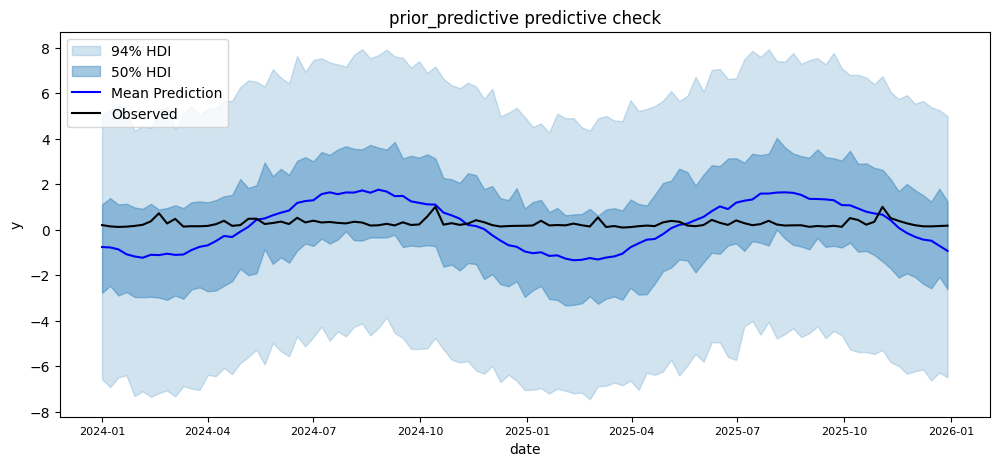

In [9]:
mmm = MMM(
    date_column="date",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=ADSTOCK_MAP[ADSTOCK_TYPE](l_max=ADSTOCK_L_MAX),
    saturation=SATURATION_MAP[SATURATION_TYPE](),
    model_config=model_config,
    time_varying_intercept=TIME_VARYING_INTERCEPT,
    time_varying_media=TIME_VARYING_MEDIA,
    yearly_seasonality=YEARLY_SEASON,
    sampler_config=SAMPLER_CONFIG,
    dag=CAUSAL_DAG, 
)

mmm_copy = copy.deepcopy(mmm)

# train/test split — 날짜 기반
test_start = pd.Timestamp(TEST_START_DATE)
data_train = variable_selected[variable_selected["date"] < test_start].reset_index(drop=True)
data_test  = variable_selected[variable_selected["date"] >= test_start].reset_index(drop=True)

y = data_train[TARGET_COLUMN].astype(float)
X = data_train[["date"] + channel_columns + control_columns].copy()

print(f"Train: {data_train['date'].min().date()} ~ {data_train['date'].max().date()} ({len(data_train)}일)")
print(f"Test:  {data_test['date'].min().date()} ~ {data_test['date'].max().date()} ({len(data_test)}일)")

mmm.build_model(X, y)

mmm.sample_prior_predictive(X, y, samples=2000)
mmm.plot_prior_predictive(figsize=(12, 5))
plt.xticks(fontsize=8)
save_plot("prior_predictive") 
plt.show()

In [10]:
mmm.fit(
    X=X,
    y=y,
    random_seed=np.random.default_rng(RANDOM_SEED),
)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

2026-03-31 14:32:48.346297: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce.3 = f64[4,4000,200]{2,1,0} reduce(f64[4,4000,1,200]{3,2,1,0} %broadcast.24, f64[] %constant.36), dimensions={2}, to_apply=%region_3.131, metadata={op_name="jit(process_fn)/jit(main)/reduce_prod" source_file="/var/folders/bl/22fkyxrs1955kfhkyc5z874h0000gn/T/tmpxilp3ihg" source_line=93}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-03-31 14:32:59.633877: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 12.292599s
Constant folding an instruction is taking > 1s:

  %reduc

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

## 3. 모델 진단

In [11]:
priors = mmm.model_config.copy()
if mmm.yearly_seasonality is None:
    priors.pop("gamma_fourier", None)
if mmm.control_columns is None:
    priors.pop("gamma_control", None)
if mmm.time_varying_intercept == True:
    priors.pop("intercept_tvp_config", None)
if mmm.time_varying_media == True:
    priors.pop("media_tvp_config", None)

prior_keys = ["intercept", "y_sigma"] + list(priors.keys())[2:-1]

summary = az.summary(data=mmm.fit_result, var_names=prior_keys)
filtered_summary = summary[
    (summary["ess_bulk"] <= 4000) |
    (summary["ess_tail"] <= 4000) |
    (summary["r_hat"] > 1.01)
]
filtered_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,0.091,0.026,0.042,0.138,0.000,0.000,3166.0,5209.0,1.00
y_sigma,0.033,0.012,0.015,0.058,0.001,0.001,172.0,318.0,1.03
gamma_control[Log Original Price (demeaned)],0.108,0.038,0.036,0.180,0.001,0.001,2246.0,5370.0,1.01
gamma_control[Top 5 SKU quantity],0.519,0.068,0.397,0.649,0.004,0.003,319.0,1518.0,1.02
gamma_control[unknown_spike_3],0.173,0.051,0.073,0.267,0.001,0.001,2434.0,3080.0,1.00
gamma_control[Homeshopping active flag],0.016,0.012,0.000,0.037,0.000,0.000,719.0,2288.0,1.01
gamma_fourier[sin_1],-0.004,0.010,-0.023,0.015,0.000,0.000,3291.0,2610.0,1.00
saturation_lam[selper_spend],0.015,0.010,0.000,0.033,0.000,0.000,3731.0,7174.0,1.00


  Saved: outputs/brand2/result/8_4_105_20260331_143053/trace_plot.png


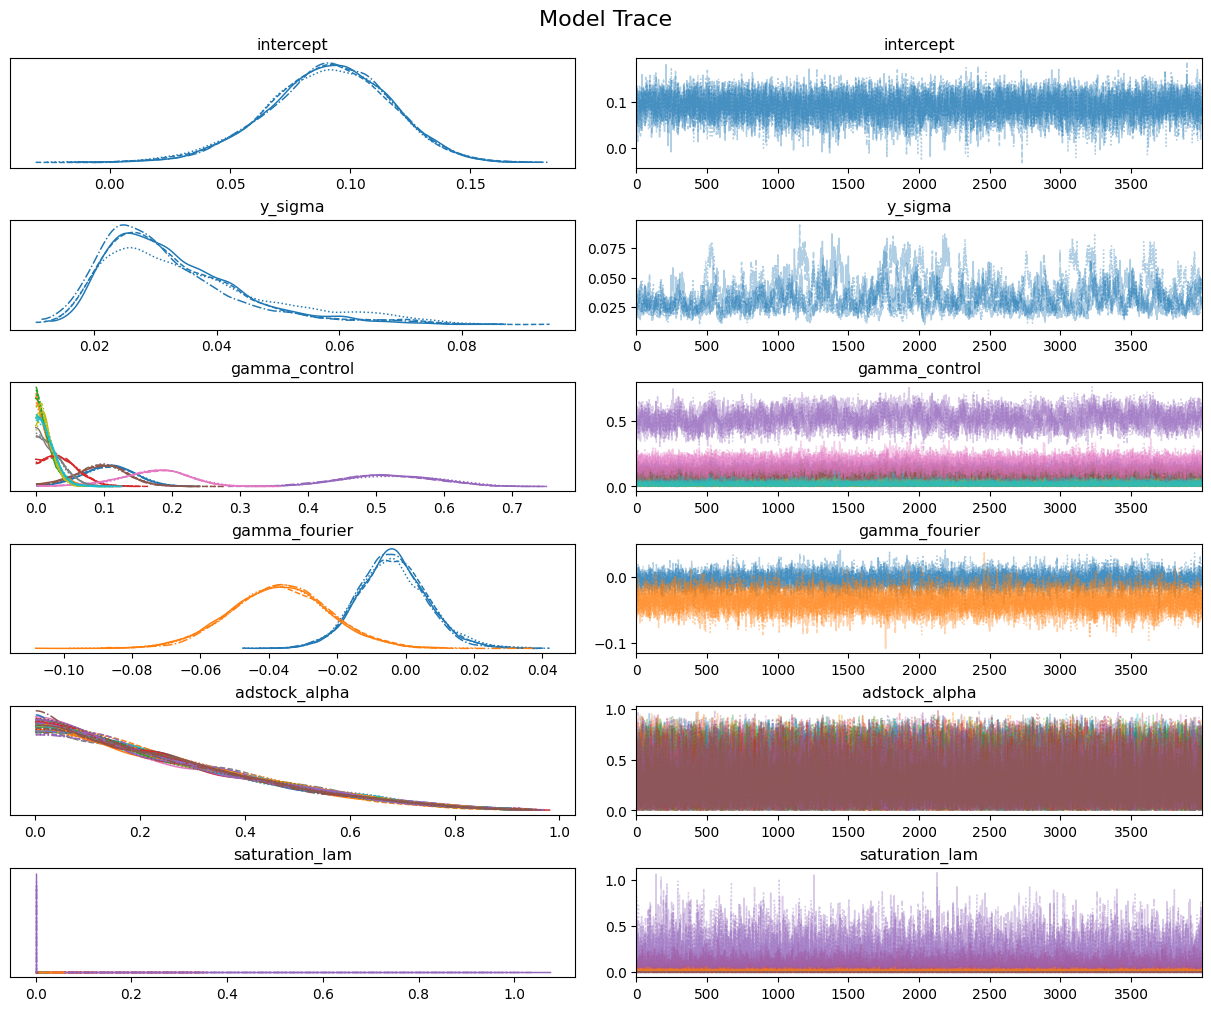

In [12]:
_ = az.plot_trace(
    data=mmm.fit_result,
    var_names=prior_keys,
    compact=True,
    backend_kwargs={"figsize": (12, 10), "layout": "constrained"},
)
plt.gcf().suptitle("Model Trace", fontsize=16)
save_plot("trace_plot")

## 4. In-sample 예측 정확도

In [13]:
mmm.sample_posterior_predictive(X, extend_idata=True, combined=True)

Sampling: [y]


Output()

<xarray.Dataset> Size: 14MB
Dimensions:  (sample: 16000, date: 105)
Coordinates:
  * date     (date) datetime64[ns] 840B 2024-01-01 2024-01-08 ... 2025-12-29
  * sample   (sample) object 128kB MultiIndex
  * chain    (sample) int64 128kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 128kB 0 1 2 3 4 5 ... 3994 3995 3996 3997 3998 3999
Data variables:
    y        (date, sample) float64 13MB 1.711e+08 1.865e+08 ... 1.518e+08
Attributes:
    created_at:                 2026-03-31T05:33:05.531765
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.22.0

  Saved: outputs/brand2/result/8_4_105_20260331_143053/posterior_predictive.png


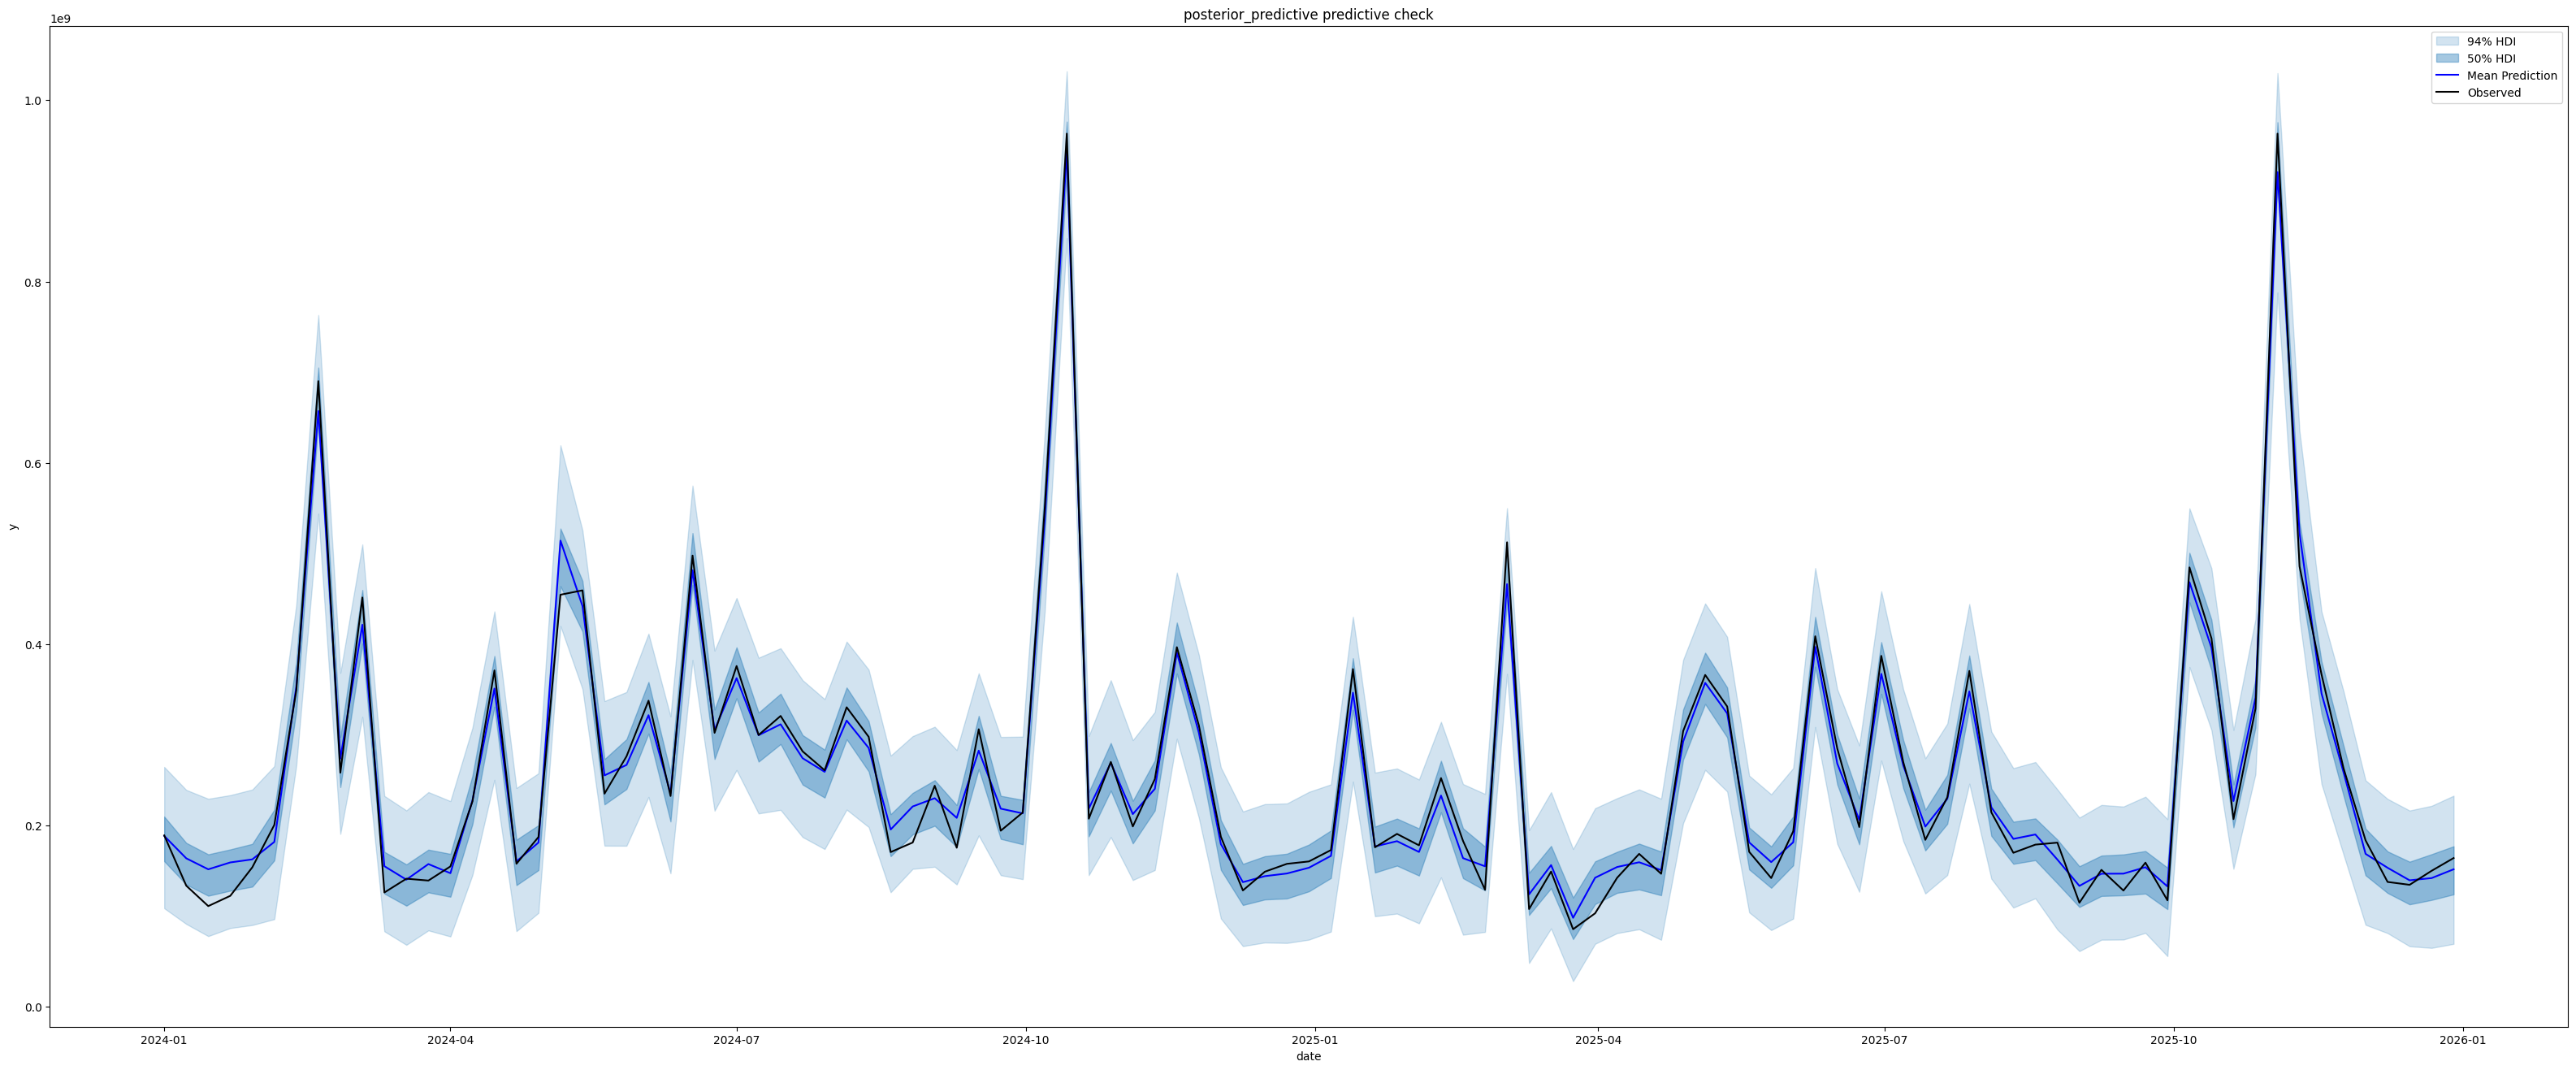

In [14]:
mmm.plot_posterior_predictive(original_scale=True, figsize=(40, 16))
save_plot("posterior_predictive")

  Saved: outputs/brand2/result/8_4_105_20260331_143053/errors.png


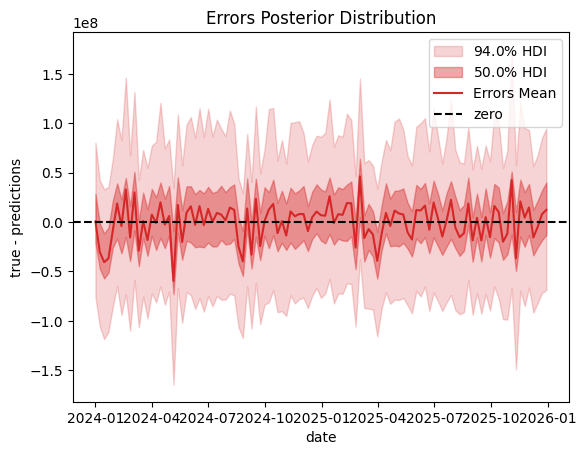

In [15]:
mmm.plot_errors(original_scale=True)
save_plot("errors")

## 5. Waterfall Decomposition

  Saved: outputs/brand2/result/8_4_105_20260331_143053/waterfall_decomposition.png


<Figure size 2000x1600 with 0 Axes>

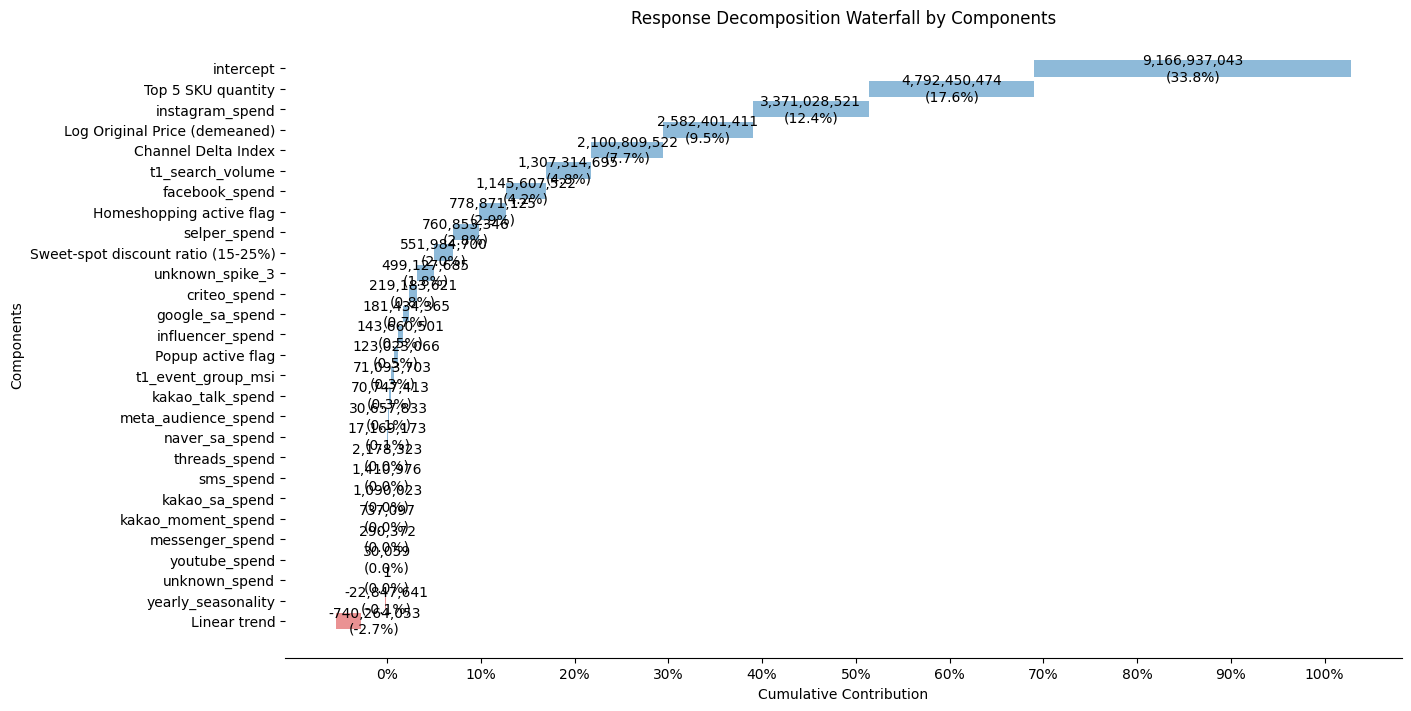

In [16]:
plt.figure(figsize=(20, 16))
mmm.plot_waterfall_components_decomposition()
save_plot("waterfall_decomposition") 
plt.show()

In [17]:
# ============================================================
#  DB Catalog 기반 Waterfall 그룹 분류
# ============================================================
import pymysql

_conn = pymysql.connect(
    host="dev-database.czyq0qigimqo.ap-northeast-2.rds.amazonaws.com",
    port=3306, user="admin", password="Shared2024!", database="modeler",
)
_cur = _conn.cursor()
_cur.execute(
    "SELECT variable_en, category FROM 2_variable_catalog WHERE set_id = %s",
    (VARIABLE_SET_ID,),
)
_catalog_map = {row[0]: row[1] for row in _cur.fetchall()}
_conn.close()

# control_columns를 catalog 기준으로 분류
seasonality_components = ["yearly_seasonality"] + [c for c in control_columns if "trend" in c]
baseline_control_components = [c for c in control_columns if "trend" not in c and _catalog_map.get(c, "Base") == "Base"]
other_control_components = [c for c in control_columns if "trend" not in c and _catalog_map.get(c) == "Promo"]

print(f"seasonality:    {seasonality_components}")
print(f"baseline (Base): {baseline_control_components}")
print(f"other (Promo):   {other_control_components}")

seasonality:    ['yearly_seasonality', 'Linear trend']
baseline (Base): ['Log Original Price (demeaned)', 'Channel Delta Index', 'Top 5 SKU quantity']
other (Promo):   ['Sweet-spot discount ratio (15-25%)', 't1_search_volume', 'unknown_spike_3', 't1_event_group_msi', 'Homeshopping active flag', 'Popup active flag']


  Saved: outputs/brand2/result/8_4_105_20260331_143053/waterfall_grouped.png


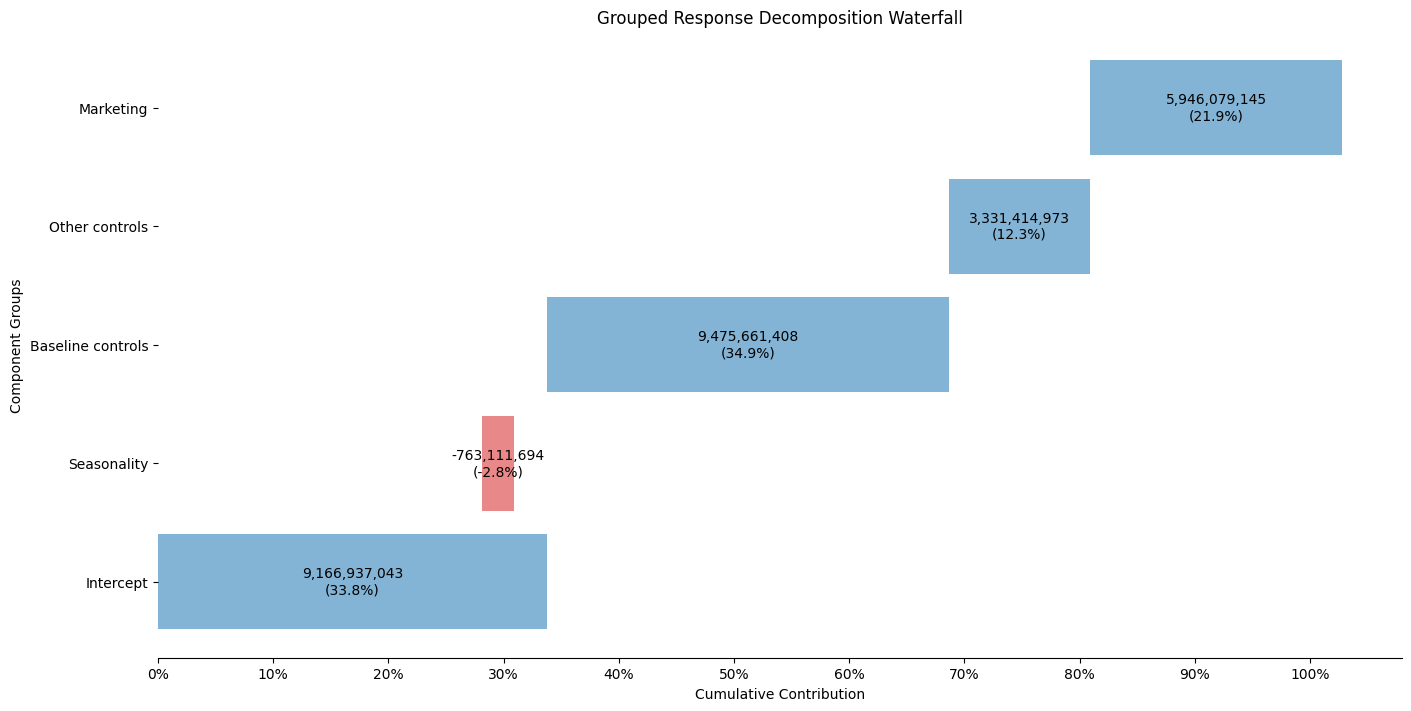

In [18]:
fig = plot_waterfall_grouped_from_mmm(
    mmm,
    intercept_name="intercept",
    seasonality_components=seasonality_components,
    baseline_control_components=baseline_control_components,
    other_control_components=other_control_components,
    marketing_components=channel_columns,
    original_scale=True,
    intercept_label="Intercept",
    seasonality_label="Seasonality",
    baseline_control_label="Baseline controls",
    other_control_label="Other controls",
    marketing_label="Marketing",
)
save_plot("waterfall_grouped")

## 6. Train/Test 평가

In [19]:
is_df, oos_df, metrics, raw = evaluate_mmm_train_test_ppc(
    mmm=mmm,
    data_train=data_train,
    data_test=data_test,
    target_col=TARGET_COLUMN,
    date_col="date",
    include_last_observations_oos=True,
)

y_scale_train = is_df["y_true"].mean()
y_scale_test  = oos_df["y_true"].mean()

metrics_df, score_df, display_df = prettify_metrics(
    metrics,
    y_scale_train=y_scale_train,
    y_scale_test=y_scale_test,
)

# Add nCRPS (normalized CRPS = CRPS / mean(y_true))
ncrps_train = float(display_df.loc[0, "CRPS"]) / y_scale_train
ncrps_test  = float(display_df.loc[1, "CRPS"]) / y_scale_test
display_df["nCRPS"] = [f"{ncrps_train:.4f}", f"{ncrps_test:.4f}"]

display_df

Sampling: [y]


Output()

Sampling: [y]


Output()

,sample,R2,MAPE,CRPS,nCRPS
0,train,0.985,7.07%,11806067.0770,0.0456
1,test,0.278,13.84%,16659002.5203,0.1035


In [20]:
# ============================================================
#  상위 주기 합계 기준 Train/Test 평가
#  - Daily 데이터 → Weekly 합계
#  - Weekly 데이터 → Monthly 합계
# ============================================================
from properscoring import crps_ensemble
from utils import r2_score, mean_absolute_percentage_error

def aggregate_metrics(pred_df, ppc_xr, output_var="y"):
    """데이터 주기를 감지하여 상위 주기로 합산 후 R2/MAPE/CRPS/nCRPS 계산"""
    df = pred_df.copy()

    # 데이터 주기 자동 감지
    date_diffs = df["date"].diff().dropna()
    median_diff = date_diffs.median().days
    is_weekly_data = median_diff >= 6

    if is_weekly_data:
        # Weekly → Monthly 합계
        agg_label = "monthly"
        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month

        agg = df.groupby(["year", "month"]).agg(
            y_true=("y_true", "sum"),
            y_pred=("y_pred", "sum"),
            n_obs=("y_true", "count"),
        ).reset_index()
        # 불완전한 월 제거 (4주 미만)
        agg = agg[agg["n_obs"] >= 4].reset_index(drop=True)
        group_keys = ["year", "month"]
    else:
        # Daily → Weekly 합계
        agg_label = "weekly"
        df["year"] = df["date"].dt.isocalendar().year.astype(int)
        df["week"] = df["date"].dt.isocalendar().week.astype(int)

        agg = df.groupby(["year", "week"]).agg(
            y_true=("y_true", "sum"),
            y_pred=("y_pred", "sum"),
            n_obs=("y_true", "count"),
        ).reset_index()
        # 불완전한 주 제거 (7일 미만)
        agg = agg[agg["n_obs"] == 7].reset_index(drop=True)
        group_keys = ["year", "week"]

    if len(agg) == 0:
        return np.nan, np.nan, np.nan, np.nan, 0, agg_label

    a_r2 = r2_score(agg["y_true"].values, agg["y_pred"].values)
    a_mape = mean_absolute_percentage_error(agg["y_true"].values, agg["y_pred"].values)

    # CRPS: posterior samples도 같은 주기로 합산
    n_obs = len(pred_df)
    samples_2d = ppc_xr[output_var].values.reshape(-1, n_obs).T  # (obs, samples)

    df["_idx"] = range(n_obs)
    idx_groups = df.groupby(group_keys)["_idx"].apply(list).reset_index()
    idx_groups.columns = group_keys + ["indices"]
    idx_groups = idx_groups.merge(agg[group_keys], on=group_keys)

    agg_samples = np.array([samples_2d[idxs].sum(axis=0) for idxs in idx_groups["indices"]])
    agg_true = agg["y_true"].values
    a_crps = float(np.mean(crps_ensemble(agg_true, agg_samples)))
    a_ncrps = a_crps / agg_true.mean()

    return a_r2, a_mape, a_crps, a_ncrps, len(agg), agg_label

# --- Train ---
is_ppc = mmm.sample_posterior_predictive(data_train, extend_idata=False, combined=False)
tr_r2, tr_mape, tr_crps, tr_ncrps, tr_n, agg_label = aggregate_metrics(is_df, is_ppc)

# --- Test ---
oos_ppc = mmm.sample_posterior_predictive(data_test, extend_idata=False, combined=False,
                                          include_last_observations=True)
te_r2, te_mape, te_crps, te_ncrps, te_n, _ = aggregate_metrics(oos_df, oos_ppc)

unit = "m" if agg_label == "monthly" else "w"
agg_display_df = pd.DataFrame([
    {"sample": f"train ({tr_n}{unit})", "R2": f"{tr_r2:.3f}", "MAPE": f"{tr_mape:.2f}%",
     "CRPS": f"{tr_crps:.2f}", "nCRPS": f"{tr_ncrps:.4f}"},
    {"sample": f"test ({te_n}{unit})", "R2": f"{te_r2:.3f}", "MAPE": f"{te_mape:.2f}%",
     "CRPS": f"{te_crps:.2f}", "nCRPS": f"{te_ncrps:.4f}"},
])

print(f"=== {agg_label.title()} Aggregate Metrics ===")
agg_display_df

Sampling: [y]


Output()

Sampling: [y]


Output()

=== Monthly Aggregate Metrics ===


,sample,R2,MAPE,CRPS,nCRPS
0,train (24m),0.991,2.92%,24405373.82,0.0216
1,test (2m),-0.277,11.22%,47168681.60,0.0733


Sampling: [y]


Output()

  Saved: outputs/brand2/result/8_4_105_20260331_143053/prediction_comparison.png


/Users/ansaejin/Desktop/renewal/module/utils.py:986: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  X_out_of_sample['date'].dt.to_pydatetime(),


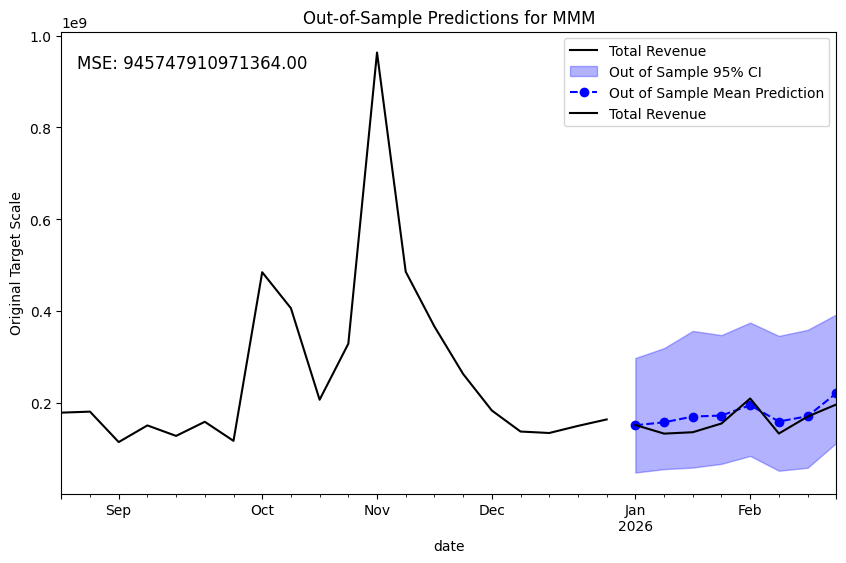

In [21]:
plot_prediction_comparison(
    data_train,
    data_test,
    mmm.sample_posterior_predictive(data_test, extend_idata=False),
    target=TARGET_COLUMN,
)
save_plot("prediction_comparison")
plt.show()

## 7. 포화 곡선 / Granger Test

In [22]:
# --- Granger Test (주석 처리: S3 업로드 대상 아님) ---
# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=FutureWarning, message=".*verbose is deprecated.*")
#     results = granger_best_lag_many(
#         variable_selected,
#         x_cols=channel_columns,
#         y_col=target_column,
#         max_lag=12,
#         criterion="first_sig",
#         alpha=0.05,
#     )
# results

In [23]:
# --- Knee Point (주석 처리: S3 업로드 대상 아님) ---
# df_knee = get_channel_contribution_knee_df(
#     mmm, start=0, stop=1.5, num=12, absolute_xrange=True, hdi_prob=0.94
# )
# df_knee.sort_values(["knee_share", "knee_contribution_mean"], ascending=[True, False])

  Saved: outputs/brand2/result/8_4_105_20260331_143053/channel_contributions_grid.png


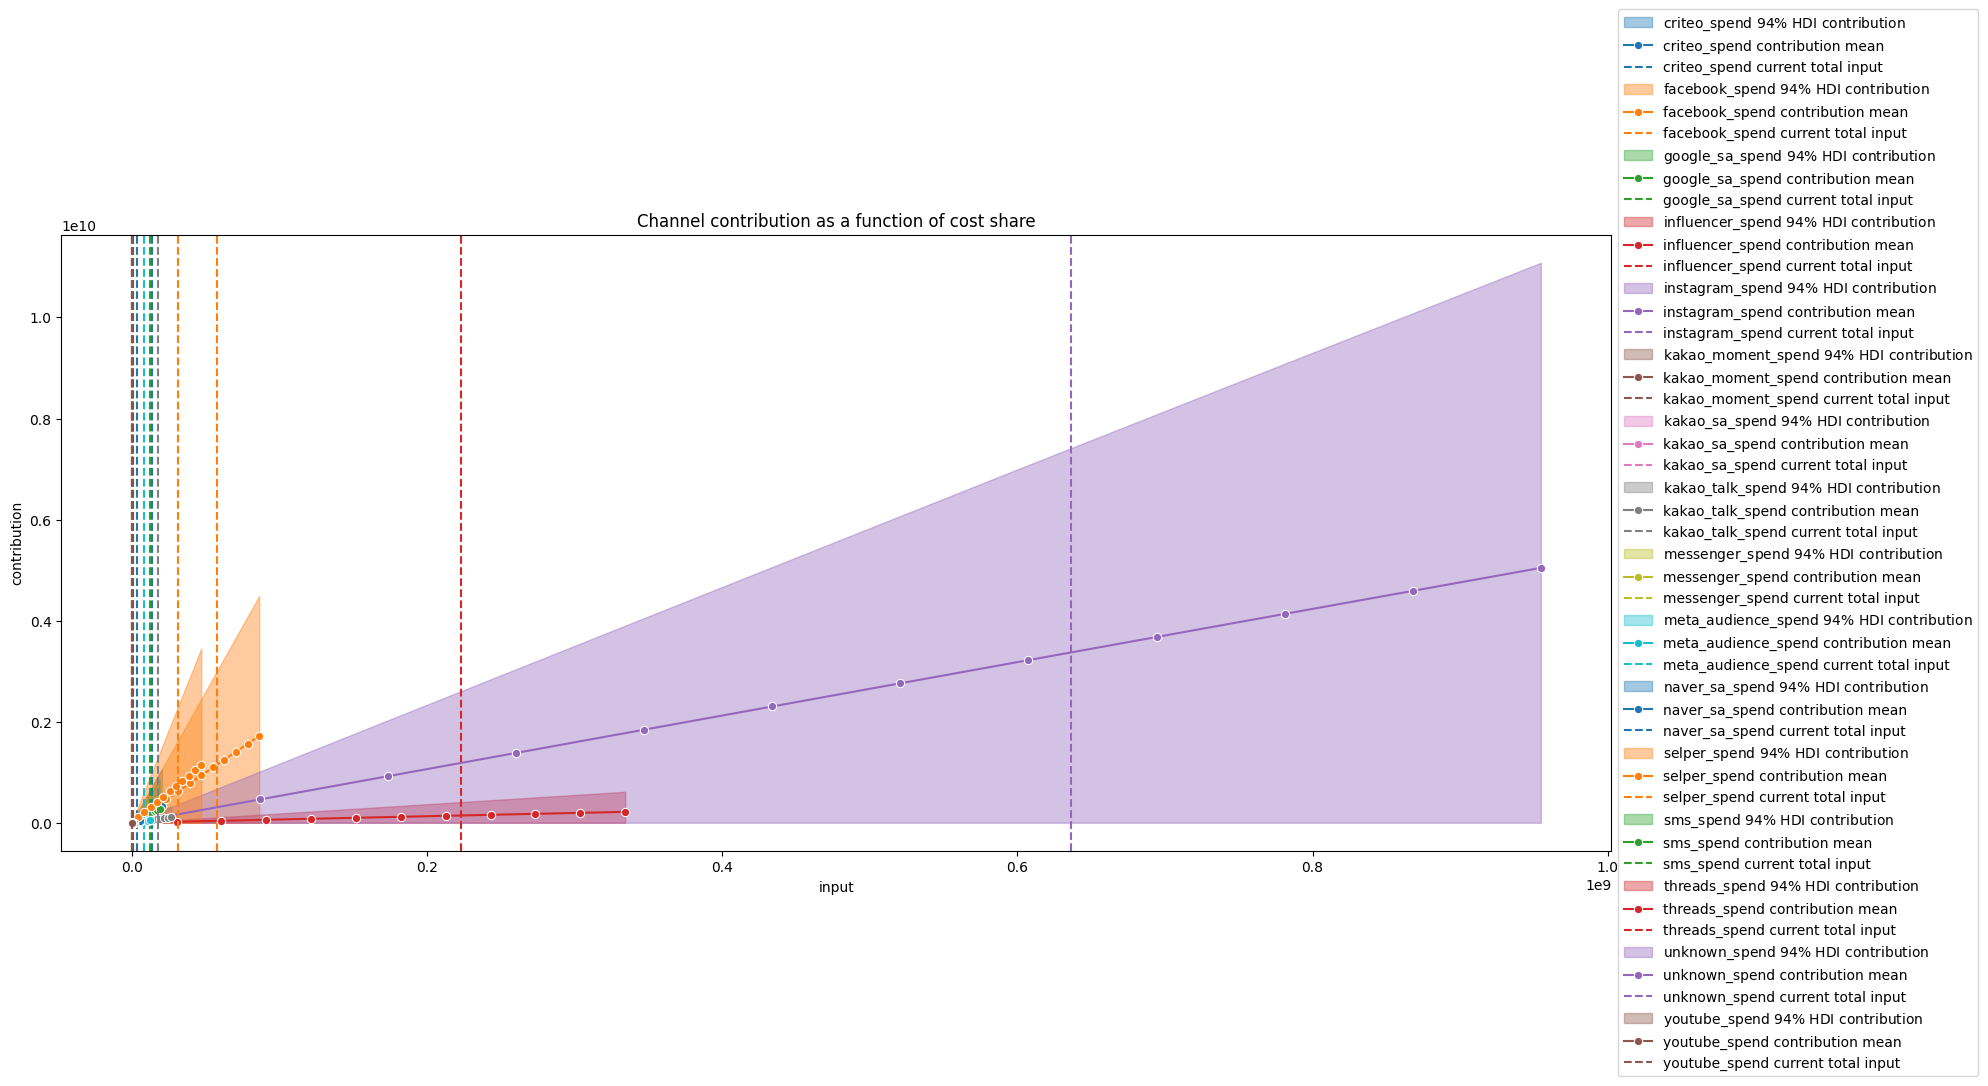

In [24]:
mmm.plot_channel_contributions_grid(
    start=0, stop=1.5, num=12, absolute_xrange=True, figsize=(20, 8))
save_plot("channel_contributions_grid")

## 8. Component Contributions

  Saved: outputs/brand2/result/8_4_105_20260331_143053/components_contributions.png


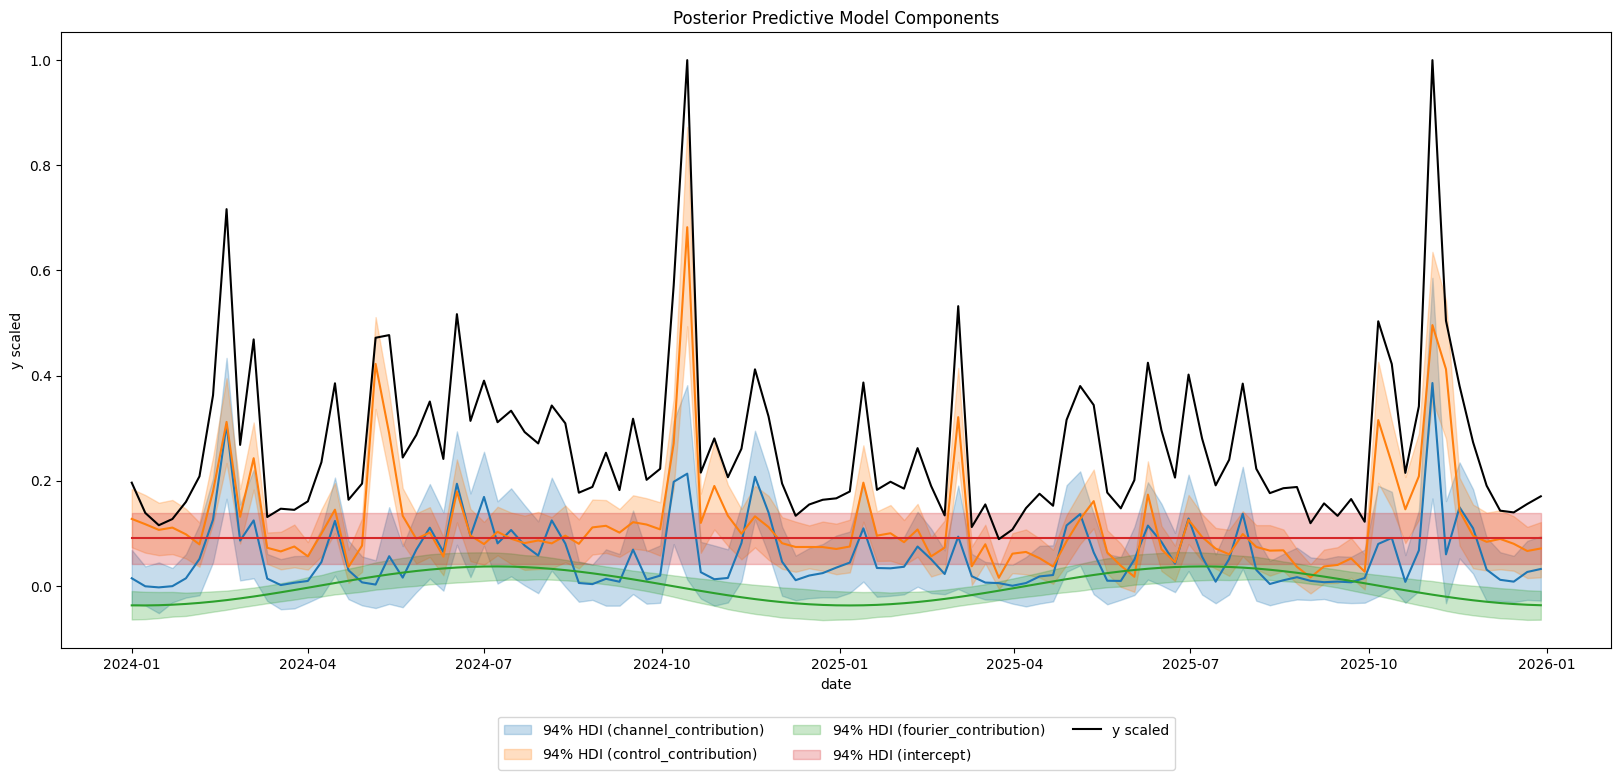

In [25]:
mmm.plot_components_contributions(figsize=(20, 8))
save_plot("components_contributions")
plt.show()

  Saved: outputs/brand2/result/8_4_105_20260331_143053/stacked_contributions.png


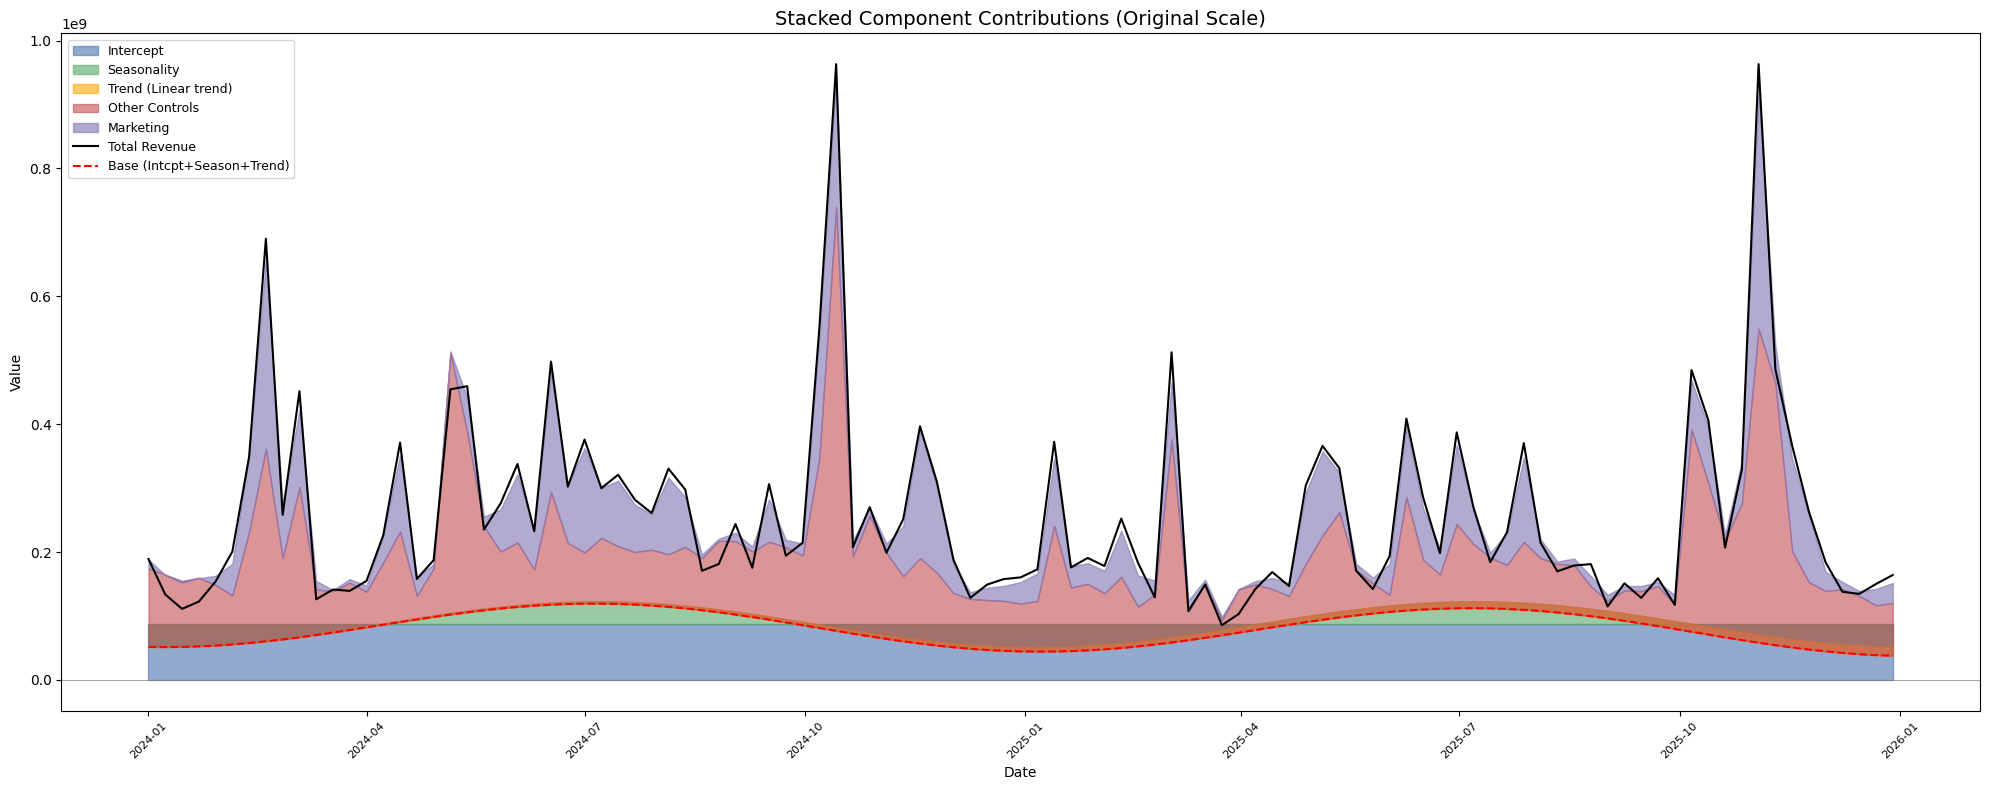

Intercept (orig): 87,304,162
Seasonality range: -35,727,083 ~ 35,724,932
Trend range: -14,100,268 ~ 0

Base (Intercept + Season + Trend):
  min: 37,837,140
  max: 119,360,796
  ✓ Base가 항상 양수


In [26]:
# ============================================================
#  Stacked Area — Base 확인 (Intercept + Seasonality + Trend)
# ============================================================
from madmatics.mmm.utils import apply_sklearn_transformer_across_dim

dates = X["date"]

# --- original scale 변환 헬퍼 ---
def to_orig(vals):
    """scaled 값을 original scale로 변환"""
    return mmm.get_target_transformer().inverse_transform(
        np.asarray(vals).reshape(-1, 1)
    ).flatten()

# --- Intercept ---
intercept_scaled = float(mmm.fit_result["intercept"].mean().values)
intercept_orig = to_orig(np.full(len(dates), intercept_scaled))

# --- Seasonality ---
season_orig = np.zeros(len(dates))
if mmm.yearly_seasonality is not None:
    season_scaled = mmm.fit_result["yearly_seasonality_contribution"].mean(dim=["chain", "draw"]).values
    # intercept + season을 함께 변환한 뒤 intercept만 뺌
    season_orig = to_orig(intercept_scaled + season_scaled) - intercept_orig

# --- Control: trend vs other 분리 ---
trend_cols = [c for c in mmm.control_columns if "trend" in c.lower()]
other_ctrl_cols = [c for c in mmm.control_columns if "trend" not in c.lower()]

trend_orig = np.zeros(len(dates))
other_ctrl_orig = np.zeros(len(dates))

if mmm.control_columns is not None and len(mmm.control_columns) > 0:
    ctrl_scaled = mmm.fit_result["control_contributions"].mean(dim=["chain", "draw"])  # (date, control)
    gamma = mmm.fit_result["gamma_control"].mean(dim=["chain", "draw"]).values          # (control,)
    ctrl_data = mmm.preprocessed_data["X"][mmm.control_columns].values                  # (date, control)

    for i, col in enumerate(mmm.control_columns):
        col_contrib_scaled = ctrl_data[:, i] * gamma[i]
        col_contrib_orig = to_orig(intercept_scaled + col_contrib_scaled) - intercept_orig
        if col in trend_cols:
            trend_orig += col_contrib_orig
        else:
            other_ctrl_orig += col_contrib_orig

# --- Channel (전체 합산) ---
channel_scaled = mmm.fit_result["channel_contributions"].mean(dim=["chain", "draw"])
if "channel" in channel_scaled.dims:
    channel_scaled = channel_scaled.sum(dim="channel").values
else:
    channel_scaled = channel_scaled.values
channel_orig = to_orig(intercept_scaled + channel_scaled) - intercept_orig

# --- 누적 쌓기 ---
layer0 = np.zeros(len(dates))
layer1 = layer0 + intercept_orig
layer2 = layer1 + season_orig
layer3 = layer2 + trend_orig
layer4 = layer3 + other_ctrl_orig
layer5 = layer4 + channel_orig

y_orig = data_train[TARGET_COLUMN].values

fig, ax = plt.subplots(figsize=(20, 8))

ax.fill_between(dates, layer0, layer1, color='#4C72B0', alpha=0.6, label='Intercept')
ax.fill_between(dates, layer1, layer2, color='#55A868', alpha=0.6, label='Seasonality')
ax.fill_between(dates, layer2, layer3, color='#FFA500', alpha=0.6, label=f'Trend ({", ".join(trend_cols)})')
ax.fill_between(dates, layer3, layer4, color='#C44E52', alpha=0.6, label='Other Controls')
ax.fill_between(dates, layer4, layer5, color='#8172B2', alpha=0.6, label='Marketing')

ax.plot(dates, y_orig, color='black', linewidth=1.5, label=TARGET_COLUMN, zorder=5)

# Base 라인
base = intercept_orig + season_orig + trend_orig
ax.plot(dates, base, color='red', linewidth=1.5, linestyle='--', label='Base (Intcpt+Season+Trend)', zorder=4)
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='-')

ax.set_title('Stacked Component Contributions (Original Scale)', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlabel('Date')
ax.set_ylabel('Value')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
save_plot("stacked_contributions")
plt.show()

# --- Base 점검 ---
print(f"Intercept (orig): {intercept_orig[0]:,.0f}")
print(f"Seasonality range: {season_orig.min():,.0f} ~ {season_orig.max():,.0f}")
if len(trend_cols) > 0:
    print(f"Trend range: {trend_orig.min():,.0f} ~ {trend_orig.max():,.0f}")
print(f"\nBase (Intercept + Season + Trend):")
print(f"  min: {base.min():,.0f}")
print(f"  max: {base.max():,.0f}")
if base.min() < 0:
    print("  ⚠ Base가 음수로 내려감!")
else:
    print("  ✓ Base가 항상 양수")

## 9. Holdout Test

In [27]:
# holdout_list = [12, 16, 20]  # 예시: 4주, 8주, 12주, 16주, 20주 홀드아웃

# multi_result = evaluate_mmm_with_multi_holdout(
#     mmm=mmm_copy,
#     data=variable_selected,
#     target=TARGET_COLUMN,
#     date_col="date",
#     holdout_list=holdout_list,
# )

# multi_result["metrics_table"]

In [28]:
# res = evaluate_mmm_weekly_and_aggregate_multi_holdout(
#     mmm=mmm_copy,
#     data=variable_selected,
#     target=TARGET_COLUMN,
#     holdout_weeks_list=(4, 13, 26, 52),
#     weekly_eval_weeks=6,
#     rolling=False,
#     store_pred_dfs=False,
#     max_crps_draws=500,
# )
# summary = res["summary"]
# summary

## 10. S3 업로드 & action-modeler 연동
- 모든 plot을 PNG로 저장 후 S3에 업로드
- 주요 지표(metrics)를 JSON으로 S3에 업로드
- action-modeler 사이트에서 결과를 확인할 수 있도록 구조화된 경로로 저장

In [29]:
# ============================================================
# S3 업로드 경로 설정
# ============================================================
s3_result      = f"{S3_PREFIX}/{BRAND_ID}/result/{RESULT_DIR_NAME}"
s3_config_set  = f"{S3_PREFIX}/{BRAND_ID}/config_set"

print(f"Local output:   {local_dir}")
print(f"S3 result:      s3://{S3_BUCKET}/{s3_result}/")
print(f"S3 config_set:  s3://{S3_BUCKET}/{s3_config_set}/")

Local output:   outputs/brand2/result/8_4_105_20260331_143053
S3 result:      s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/
S3 config_set:  s3://action-kpi-bucket/model_result/brand2/config_set/


In [30]:
# ============================================================
# 지표 + 모델 설정 JSON 저장
# ============================================================
metrics_output = {
    "brand_id": BRAND_ID,
    "variable_set_id": VARIABLE_SET_ID,
    "group_id": GROUP_ID,
    "config_set_id": CONFIG_SET_ID,
    "run_id": RUN_ID,
    "note": NOTE,

    # --- 모델 설정 ---
    "model_settings": {
        "date_column": mmm.date_column,
        "channel_columns": list(mmm.channel_columns),
        "control_columns": list(mmm.control_columns) if mmm.control_columns is not None else [],
        "target_column": TARGET_COLUMN,
        "adstock": {
            "type": type(mmm.adstock).__name__,
            "l_max": mmm.adstock.l_max,
        },
        "saturation": {
            "type": type(mmm.saturation).__name__,
        },
        "time_varying_intercept": mmm.time_varying_intercept,
        "time_varying_media": mmm.time_varying_media,
        "yearly_seasonality": mmm.yearly_seasonality,
        "dag": getattr(mmm, "dag", None),
        "sampler_config": mmm.sampler_config,
        "model_config": {
            k: str(v) for k, v in mmm.model_config.items()
        },
    },

    # --- 데이터 정보 ---
    "data_info": {
        "var_names": var_names,
        "n_total": len(variable_selected),
        "n_train": len(data_train),
        "n_test": len(data_test),
        "split_ratio": round(len(data_train) / len(variable_selected), 4),
        "test_start_date": TEST_START_DATE,
        "date_range_train": [str(data_train["date"].min()), str(data_train["date"].max())],
        "date_range_test": [str(data_test["date"].min()), str(data_test["date"].max())],
    },

    # --- 평가 지표 (일별) ---
    "train_test_metrics": display_df.to_dict(orient="records"),

    # --- 평가 지표 (주간 합계) ---
    "aggregate_metrics": agg_display_df.to_dict(orient="records"),
    "aggregate_level": agg_label,
}

metrics_path = local_dir / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_output, f, ensure_ascii=False, indent=2, default=str)

print(f"Metrics saved: {metrics_path}")

Metrics saved: outputs/brand2/result/8_4_105_20260331_143053/metrics.json


In [31]:
# ============================================================
# S3 업로드
# ============================================================
uploaded = []

# --- 1) result 업로드 (metrics.json + plot PNGs) ---
print("=== Result 업로드 ===")
for file_path in local_dir.iterdir():
    s3_key = f"{s3_result}/{file_path.name}"
    content_type = "image/png" if file_path.suffix == ".png" else "application/json"
    s3.upload_file(
        str(file_path), S3_BUCKET, s3_key,
        ExtraArgs={"ContentType": content_type},
    )
    uploaded.append(s3_key)
    print(f"  s3://{S3_BUCKET}/{s3_key}")

# --- 2) config_set 업로드 ---
print("\n=== Config Set ===")
config_key = f"{s3_config_set}/config_set_{CONFIG_SET_ID}.json"

if CONFIG_FROM_S3:
    # S3에서 불러온 config → 이미 존재하므로 재업로드 안 함
    print(f"  (S3 모드) 기존 config 사용, 업로드 스킵: {config_key}")
else:
    # Manual config → 같은 ID가 이미 있는지 확인
    config_exists = False
    try:
        s3.head_object(Bucket=S3_BUCKET, Key=config_key)
        config_exists = True
    except s3.exceptions.ClientError:
        pass

    if config_exists:
        print(f"  config_set_{CONFIG_SET_ID}.json 이 이미 S3에 존재합니다!")
        print(f"  덮어쓰지 않습니다. CONFIG_SET_ID를 변경해주세요.")
    else:
        config_set_data = {
            "config_set_id": CONFIG_SET_ID,
            "adstock": {
                "type": type(mmm.adstock).__name__,
                "l_max": mmm.adstock.l_max,
            },
            "saturation": {
                "type": type(mmm.saturation).__name__,
            },
            "yearly_seasonality": YEARLY_SEASON,
            "time_varying_intercept": TIME_VARYING_INTERCEPT,
            "time_varying_media": TIME_VARYING_MEDIA,
            "sampler_config": SAMPLER_CONFIG,
            "train_ratio": round(len(data_train) / len(variable_selected), 4),
            "random_seed": RANDOM_SEED,
            "model_config": {k: str(v) for k, v in mmm.model_config.items()},
        }
        s3.put_object(
            Bucket=S3_BUCKET,
            Key=config_key,
            Body=json.dumps(config_set_data, ensure_ascii=False, indent=2, default=str),
            ContentType="application/json",
        )
        uploaded.append(config_key)
        print(f"  새 config 업로드: s3://{S3_BUCKET}/{config_key}")

print(f"\n총 {len(uploaded)}개 파일 업로드 완료.")

=== Result 업로드 ===
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/metrics.json
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/errors.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/waterfall_grouped.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/trace_plot.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/prior_predictive.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/components_contributions.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/stacked_contributions.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/posterior_predictive.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/channel_contributions_grid.png
  s3://action-kpi-bucket/model_result/brand2/result/8_4_105_20260331_143053/prediction_comparison.png
  

## 11. 전체 기간 학습 + 모델 저장

In [32]:
# ============================================================
#  전체 기간으로 재학습 후 dill 파일로 저장
# ============================================================
import dill

# 전체 데이터로 새 모델 생성 + 학습
mmm_full = MMM(
    date_column="date",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=ADSTOCK_MAP[ADSTOCK_TYPE](l_max=ADSTOCK_L_MAX),
    saturation=SATURATION_MAP[SATURATION_TYPE](),
    model_config=model_config,
    time_varying_intercept=TIME_VARYING_INTERCEPT,
    time_varying_media=TIME_VARYING_MEDIA,
    yearly_seasonality=YEARLY_SEASON,
    sampler_config=SAMPLER_CONFIG,
    dag=CAUSAL_DAG,
)

X_full = variable_selected[["date"] + channel_columns + control_columns].copy()
y_full = variable_selected[TARGET_COLUMN].astype(float)

print(f"Full data: {variable_selected['date'].min().date()} ~ {variable_selected['date'].max().date()} ({len(variable_selected)}행)")

mmm_full.build_model(X_full, y_full)
mmm_full.fit(X=X_full, y=y_full, random_seed=np.random.default_rng(RANDOM_SEED))

# _time_resolution 자동 감지 (action_worker 호환)
date_diffs = pd.Series(X_full["date"]).diff().dropna().dt.days.median()
mmm_full._time_resolution = int(date_diffs)
print(f"_time_resolution: {mmm_full._time_resolution}")

# dill 저장
dill_path = local_dir / f"mmm_full_{RESULT_DIR_NAME}.dill"
with open(dill_path, "wb") as f:
    dill.dump(mmm_full, f)

print(f"\nModel saved: {dill_path}")
print(f"File size: {dill_path.stat().st_size / 1024 / 1024:.1f} MB")

Full data: 2024-01-01 ~ 2026-02-23 (113행)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

2026-03-31 14:35:16.575794: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce.3 = f64[4,4000,200]{2,1,0} reduce(f64[4,4000,1,200]{3,2,1,0} %broadcast.24, f64[] %constant.36), dimensions={2}, to_apply=%region_3.131, metadata={op_name="jit(process_fn)/jit(main)/reduce_prod" source_file="/var/folders/bl/22fkyxrs1955kfhkyc5z874h0000gn/T/tmpgygn1i0q" source_line=93}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-03-31 14:35:27.053331: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 12.481301s
Constant folding an instruction is taking > 2s:

  %reduc

_time_resolution: 7

Model saved: outputs/brand2/result/8_4_105_20260331_143053/mmm_full_8_4_105_20260331_143053.dill
File size: 720.6 MB


In [33]:
# ============================================================
#  전체 기간 학습 모델 MAPE 측정
# ============================================================
from sklearn.metrics import mean_absolute_percentage_error

mmm_full.sample_posterior_predictive(X_full, extend_idata=True, combined=True)
y_pred_full = mmm_full.idata.posterior_predictive["y"].mean(dim=["chain", "draw"]).values

# original scale 복원
y_pred_orig = mmm_full.get_target_transformer().inverse_transform(y_pred_full.reshape(-1, 1)).flatten()
y_true_orig = y_full.values

mape_full = mean_absolute_percentage_error(y_true_orig, y_pred_orig) * 100
print(f"Full-period model MAPE: {mape_full:.2f}%")


Output()

Full-period model MAPE: 7.73%


In [36]:
# ============================================================
#  action-kpi prediction 테스트
# ============================================================
import sys
sys.path.insert(0, "/Users/ansaejin/Desktop/action_worker")
import pymysql

from handlers.predict import handle_predict

result = handle_predict(mmm_full, {
    "start_date": "2026-02-02",
    "end_date": "2026-02-28",
})

# DB에서 실제 매출 조회 (trade=retail)
_conn = pymysql.connect(
    host="dev-database.czyq0qigimqo.ap-northeast-2.rds.amazonaws.com",
    port=3306, user="admin", password="Shared2024!", database="brand_data",
)
_cur = _conn.cursor()
_cur.execute("""
    SELECT SUM(sales_amount) 
    FROM 2_mart_revenue_product_store
    WHERE trade = 'RETAIL'
      AND date >= '2026-02-02' AND date <= '2026-02-28'
""")
actual_sum = float(_cur.fetchone()[0] or 0)
_conn.close()

pred_sum = result["target"]
error_pct = (pred_sum - actual_sum) / actual_sum * 100

print(f"=== 2026년 2월 예측 vs 실제 (RETAIL) ===")
print(f"Actual (DB):           {actual_sum:,.0f}")
print(f"Predicted:             {pred_sum:,.0f}")
print(f"Error:                 {error_pct:+.2f}%")
print(f"")
print(f"Baseline Contribution: {result['baseline_contribution']:,.0f}")
print(f"Marketing Contribution: {result['marketing_contribution']:,.0f}")
print(f"ROI:                   {result['roi']:.2f}%")

Output()

=== 2026년 2월 예측 vs 실제 (RETAIL) ===
Actual (DB):           660,018,440
Predicted:             725,715,753
Error:                 +9.95%

Baseline Contribution: 650,487,745
Marketing Contribution: 75,228,009
ROI:                   200.96%


In [38]:
# ============================================================
#  action-kpi prediction 테스트 — 3월
# ============================================================
result_mar = handle_predict(mmm_full, {
    "start_date": "2026-03-02",
    "end_date": "2026-03-29",
})

# DB에서 실제 매출 조회 (trade=retail)
_conn = pymysql.connect(
    host="dev-database.czyq0qigimqo.ap-northeast-2.rds.amazonaws.com",
    port=3306, user="admin", password="Shared2024!", database="brand_data",
)
_cur = _conn.cursor()
_cur.execute("""
    SELECT SUM(sales_amount) 
    FROM 2_mart_revenue_product_store
    WHERE trade = 'RETAIL'
      AND date >= '2026-03-02' AND date <= '2026-03-29'
""")
actual_mar = float(_cur.fetchone()[0] or 0)
_conn.close()

pred_mar = result_mar["target"]
error_mar = (pred_mar - actual_mar) / actual_mar * 100

print(f"=== 2026년 3월 예측 vs 실제 (RETAIL) ===")
print(f"Actual (DB):           {actual_mar:,.0f}")
print(f"Predicted:             {pred_mar:,.0f}")
print(f"Error:                 {error_mar:+.2f}%")
print(f"")
print(f"Baseline Contribution: {result_mar['baseline_contribution']:,.0f}")
print(f"Marketing Contribution: {result_mar['marketing_contribution']:,.0f}")
print(f"ROI:                   {result_mar['roi']:.2f}%")

Output()

=== 2026년 3월 예측 vs 실제 (RETAIL) ===
Actual (DB):           498,697,219
Predicted:             1,005,459,891
Error:                 +101.62%

Baseline Contribution: 755,827,098
Marketing Contribution: 249,632,793
ROI:                   666.84%
